In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict

In [2]:
filename = 'full_file.csv'  # Replace with your CSV path
df = pd.read_csv(filename)

# Required columns
required_cols = ['user_id', 'order_id', 'product_id', 'add_to_cart_order', 'order_dow', 'order_hour_of_day']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")

In [3]:
# 2️⃣ Sort and Create Lag Features (shift only within orders)
# -----------------------------
df = df.sort_values(['user_id', 'order_id', 'add_to_cart_order'])
df['lag1'] = df.groupby(['user_id', 'order_id'])['product_id'].shift(1)
df['lag2'] = df.groupby(['user_id', 'order_id'])['product_id'].shift(2)
df['next_product'] = df.groupby(['user_id', 'order_id'])['product_id'].shift(-1)

df = df.dropna(subset=['lag1', 'lag2', 'next_product'])
df[['lag1','lag2','next_product']] = df[['lag1','lag2','next_product']].astype(int)

In [4]:
# 3️⃣ Train/Test Split by order (no leakage)
# -----------------------------
orders = df['order_id'].unique()
np.random.seed(42)
np.random.shuffle(orders)
train_orders, test_orders = np.split(orders, [int(len(orders) * 0.8)])

train_df = df[df['order_id'].isin(train_orders)].copy()
test_df = df[df['order_id'].isin(test_orders)].copy()

#print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

In [5]:
# 4️⃣ Build Transition Counts and Probabilities (context-aware)
# -----------------------------
def build_transition_probs_with_context(df, group_cols):
    counts = df.groupby(list(group_cols) + ['order_dow','order_hour_of_day','next_product']).size().reset_index(name='count')
    counts['prob'] = counts['count'] / counts.groupby(list(group_cols)+['order_dow','order_hour_of_day'])['count'].transform('sum')
    return counts

# 3-item + context
counts_3_ctx = build_transition_probs_with_context(train_df, ['lag2','lag1','product_id'])
# 2-item + context
counts_2_ctx = build_transition_probs_with_context(train_df, ['lag1','product_id'])
# 1-item (no context)
counts_1 = train_df.groupby(['product_id','next_product']).size().reset_index(name='count')
counts_1['prob'] = counts_1['count'] / counts_1.groupby('product_id')['count'].transform('sum')
# Global popularity fallback
global_counts = train_df['next_product'].value_counts(normalize=True).reset_index()
global_counts.columns = ['product_id','prob']

In [6]:
# 5️⃣ Build Lookup Dictionaries for Fast Prediction
# -----------------------------
def build_lookup_dict_with_context(df, key_cols):
    d = defaultdict(list)
    for row in df.itertuples(index=False):
        key = tuple(getattr(row, col) for col in key_cols) + (row.order_dow, row.order_hour_of_day)
        d[key].append((row.next_product,row.prob))
    for key in d:
        d[key].sort(key=lambda x: x[1], reverse=True)
    return d

dict_3_ctx = build_lookup_dict_with_context(counts_3_ctx, ['lag2','lag1','product_id'])
dict_2_ctx = build_lookup_dict_with_context(counts_2_ctx, ['lag1','product_id'])

dict_1 = defaultdict(list)
for row in counts_1.itertuples(index=False):
    dict_1[(row.product_id,)].append((row.next_product,row.prob))
for key in dict_1:
    dict_1[key].sort(key=lambda x: x[1], reverse=True)

global_list = global_counts.values.tolist()  # [(product_id,prob),...]

In [7]:
# 6️⃣ Prediction Function with Backoff & Context
# -----------------------------
def predict_next_product(p2, p1, p0, order_dow, order_hour, top_k=5):
    # 3-item + context
    key3 = (p2,p1,p0,order_dow,order_hour)
    if key3 in dict_3_ctx:
        return [p[0] for p in dict_3_ctx[key3][:top_k]]
    # 2-item + context
    key2 = (p1,p0,order_dow,order_hour)
    if key2 in dict_2_ctx:
        return [p[0] for p in dict_2_ctx[key2][:top_k]]
    # 1-item
    key1 = (p0,)
    if key1 in dict_1:
        return [p[0] for p in dict_1[key1][:top_k]]
    # Global fallback
    return [p[0] for p in global_list[:top_k]]

In [8]:
# 7️⃣ Evaluation (sample 30k rows for speed)
# -----------------------------
test_sample = test_df.sample(min(30000,len(test_df)), random_state=42)

top_k = 5
hits = 0
precision_sum = 0
reciprocal_rank_sum = 0
predicted_items = set()

for row in test_sample.itertuples(index=False):
    preds = predict_next_product(row.lag2,row.lag1,row.product_id,row.order_dow,row.order_hour_of_day,top_k)
    predicted_items.update(preds)
    if row.next_product in preds:
        hits += 1
        rank = preds.index(row.next_product)+1
        reciprocal_rank_sum += 1/rank
        precision_sum += 1/top_k
    else:
        precision_sum += 0

n = len(test_sample)
hit_rate = hits/n
precision = precision_sum/n
mrr = reciprocal_rank_sum/n
recall = hit_rate
coverage = len(predicted_items)/train_df['product_id'].nunique()

print(f"Evaluation Metrics (Top-{top_k}):")
print(f"HitRate@{top_k}: {hit_rate:.4f}")
print(f"Precision@{top_k}: {precision:.4f}")
print(f"MRR: {mrr:.4f}")
print(f"Recall@{top_k}: {recall:.4f}")
print(f"Coverage@{top_k}: {coverage:.4f}")

Evaluation Metrics (Top-5):
HitRate@5: 0.0661
Precision@5: 0.0132
MRR: 0.0389
Recall@5: 0.0661
Coverage@5: 0.2264


In [9]:
def predict_with_config(row, config, top_k=5):

    use_lag2 = config.get('lag2', True)
    use_lag1 = config.get('lag1', True)
    use_product = config.get('product_id', True)
    use_time = config.get('time', True)

    # Build keys dynamically
    key_parts_3 = []
    key_parts_2 = []

    if use_lag2: key_parts_3.append(row.lag2)
    if use_lag1: key_parts_3.append(row.lag1)
    if use_product: key_parts_3.append(row.product_id)

    if use_lag1: key_parts_2.append(row.lag1)
    if use_product: key_parts_2.append(row.product_id)

    if use_time:
        key_parts_3 += [row.order_dow, row.order_hour_of_day]
        key_parts_2 += [row.order_dow, row.order_hour_of_day]

    key3 = tuple(key_parts_3)
    key2 = tuple(key_parts_2)

    if key3 in dict_3_ctx:
        return [p[0] for p in dict_3_ctx[key3][:top_k]]

    if key2 in dict_2_ctx:
        return [p[0] for p in dict_2_ctx[key2][:top_k]]

    if use_product:
        key1 = (row.product_id,)
        if key1 in dict_1:
            return [p[0] for p in dict_1[key1][:top_k]]

    return [p[0] for p in global_list[:top_k]]

In [10]:
def evaluate_config(config):
    sample = test_df.sample(min(10000,len(test_df)), random_state=42)

    hits = 0
    for row in sample.itertuples(index=False):
        preds = predict_with_config(row, config)
        if row.next_product in preds:
            hits += 1

    return hits / len(sample)

In [11]:
configs = {
    "full_model": {'lag2':True,'lag1':True,'product_id':True,'time':True},
    "no_time": {'lag2':True,'lag1':True,'product_id':True,'time':False},
    "no_lag2": {'lag2':False,'lag1':True,'product_id':True,'time':True},
    "no_lag1": {'lag2':False,'lag1':False,'product_id':True,'time':True},
    "no_product": {'lag2':True,'lag1':True,'product_id':False,'time':True},
}

In [12]:
results = {}

for name, config in configs.items():
    score = evaluate_config(config)
    results[name] = score
    print(f"{name}: {score:.4f}")

base = results['full_model']

print("\nFeature Impact:")
print(f"lag2 impact: {base - results['no_lag2']:.4f}")
print(f"lag1 impact: {base - results['no_lag1']:.4f}")
print(f"time impact: {base - results['no_time']:.4f}")
print(f"product_id impact: {base - results['no_product']:.4f}")

full_model: 0.0641
no_time: 0.0704
no_lag2: 0.0640
no_lag1: 0.0704
no_product: 0.0378

Feature Impact:
lag2 impact: 0.0001
lag1 impact: -0.0063
time impact: -0.0063
product_id impact: 0.0263


/tmp/ipykernel_15018/151076647.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette="Blues_r", ax=axes[0])
/tmp/ipykernel_15018/151076647.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)
/tmp/ipykernel_15018/151076647.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='feature', y='impact', data=impact_df, palette=impact_colors, ax=axes[1])


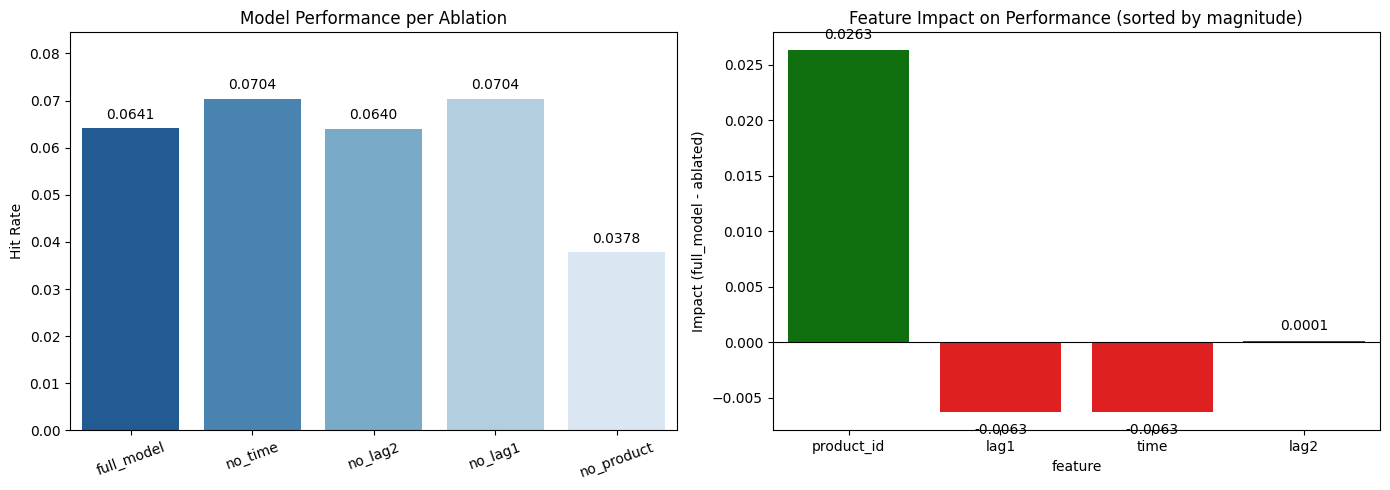

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your results
results = {
    'full_model': 0.0641,
    'no_time': 0.0704,
    'no_lag2': 0.0640,
    'no_lag1': 0.0704,
    'no_product': 0.0378
}

# Feature impact
feature_impact = {
    'product_id': results['full_model'] - results['no_product'],
    'lag1': results['full_model'] - results['no_lag1'],
    'lag2': results['full_model'] - results['no_lag2'],
    'time': results['full_model'] - results['no_time']
}

# Convert to DataFrame for sorting
impact_df = pd.DataFrame({
    'feature': list(feature_impact.keys()),
    'impact': list(feature_impact.values())
})

# Sort by absolute impact
impact_df['abs_impact'] = impact_df['impact'].abs()
impact_df = impact_df.sort_values('abs_impact', ascending=False)

# Colors: green if positive, red if negative
impact_colors = ['green' if v >=0 else 'red' for v in impact_df['impact']]

# -----------------------------
# Combined figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 1️⃣ Left: Raw performance per ablation
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="Blues_r", ax=axes[0])
axes[0].set_title("Model Performance per Ablation")
axes[0].set_ylabel("Hit Rate")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)
axes[0].set_ylim(0, max(results.values())*1.2)

# Annotate bars
for i, v in enumerate(results.values()):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha='center', fontsize=10)

# 2️⃣ Right: Feature impact sorted by magnitude
sns.barplot(x='feature', y='impact', data=impact_df, palette=impact_colors, ax=axes[1])
axes[1].set_title("Feature Impact on Performance (sorted by magnitude)")
axes[1].set_ylabel("Impact (full_model - ablated)")
axes[1].axhline(0, color='black', linewidth=0.8)

# Annotate bars
for i, row in enumerate(impact_df.itertuples()):
    v = row.impact
    axes[1].text(i, v + 0.001 if v>=0 else v - 0.002, f"{v:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()